# Network summary — Dataset 3 (Erdős–Rényi network, 10 000 nodes)

Structural characteristics of the ER network (structure only — no balance sheet):
number of nodes/edges, density, average degree, reciprocity, clustering coefficient,
assortativity, connected components, average path length and diameter.
All 10 000 node ids are included, so isolated nodes count towards the metrics.

Outputs (`src/data/network_summary/`):
- `dataset_3_summary.csv` — one column of metrics
- `dataset_3_layout.csv` — spring-layout coordinates used for the graph figure

The combined table + three-graph figure lives in `../network_summary_table.ipynb`.

In [1]:
import sys
from pathlib import Path

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path

OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'network_summary'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB_DIR = PROJECT_ROOT / 'src' / 'notebooks' / '00_notes' / 'dataset_3'

DATASET_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_3'
N = 10000  # ER network has 10000 nodes (ids 1..N), incl. isolated

## Load the network

In [2]:
e = pd.read_csv(DATASET_DIR / 'edges.csv')

G = nx.DiGraph()
G.add_nodes_from(range(1, N + 1))
G.add_edges_from(e[['from', 'to']].itertuples(index=False, name=None))
print(f'{G.number_of_nodes()} nodes, {G.number_of_edges()} directed edges')

10000 nodes, 9056 directed edges


## Summary metrics

Clustering, assortativity, path length and diameter use the undirected projection;
path length and diameter are computed on the largest connected component (LCC).

In [3]:
def network_summary(G: nx.DiGraph) -> dict:
    """Structural summary of a directed network.

    Clustering, assortativity, path length and diameter are computed on the
    undirected projection; path length and diameter on its largest connected
    component (BFS distances via scipy, C speed).
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    U = nx.Graph(G)  # undirected projection (reciprocal pairs collapse)

    components = list(nx.connected_components(U))
    lcc_nodes = max(components, key=len)
    U_lcc = U.subgraph(lcc_nodes)

    A = nx.to_scipy_sparse_array(U_lcc, format='csr', weight=None)
    D = shortest_path(A, method='D', unweighted=True, directed=False)
    finite = D[np.isfinite(D) & (D > 0)]

    degrees = np.array([d for _, d in G.degree()])  # in + out

    return {
        'n_nodes': n,
        'n_edges': m,
        'density': nx.density(G),
        'avg_degree': degrees.mean(),
        'max_degree': degrees.max(),
        'reciprocity': nx.reciprocity(G),
        'avg_clustering': nx.average_clustering(U),
        'degree_assortativity': nx.degree_assortativity_coefficient(U),
        'n_components': len(components),
        'lcc_size': len(lcc_nodes),
        'lcc_share': len(lcc_nodes) / n,
        'avg_path_length': finite.mean(),
        'diameter': finite.max(),
    }


In [4]:
summary = pd.DataFrame({'value': pd.Series(network_summary(G))})
summary.index.name = 'metric'
summary.to_csv(OUT_DIR / 'dataset_3_summary.csv')
summary

,value
metric,
n_nodes,10000.000000
n_edges,9056.000000
density,0.000091
avg_degree,1.811200
max_degree,9.000000
reciprocity,0.000000
avg_clustering,0.000120
degree_assortativity,-0.014022
n_components,1958.000000


## Graph figure

Spring layout of the largest connected component (the ER graph also has many small
components and isolated nodes — the LCC share is in the table above).
Coordinates are saved for reuse.

In [5]:
U = nx.Graph(G)
lcc = max(nx.connected_components(U), key=len)
U_lcc = U.subgraph(lcc)

# A wider spring constant (k) spreads this sparse ER graph so the dense core and the
# dendritic branches read as an airy "dandelion" instead of a solid blob.
pos = nx.spring_layout(U_lcc, seed=42, iterations=80, k=3.0 / np.sqrt(U_lcc.number_of_nodes()))
pd.DataFrame([(n, x, y) for n, (x, y) in pos.items()], columns=['node', 'x', 'y']) \
    .to_csv(OUT_DIR / 'dataset_3_layout.csv', index=False)
print(f'layout: {len(pos)} nodes')

layout: 7403 nodes


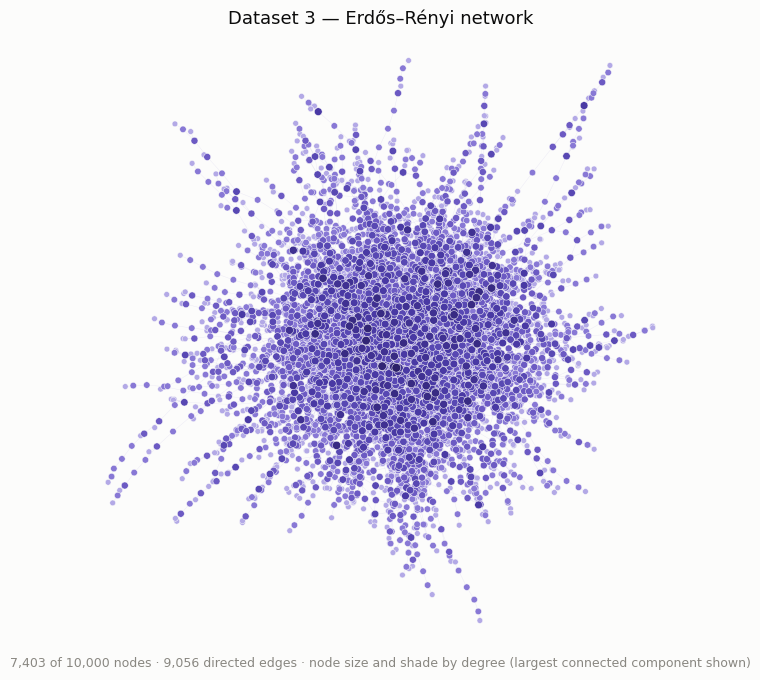

In [ ]:

# and every edge drawn once as a single receding LineCollection.
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

SURFACE, INK, MUTED = '#fcfcfb', '#0b0b0b', '#898781'
VIOLET_RAMP = LinearSegmentedColormap.from_list('violet', ['#b3a9e6', '#7a68cf', '#4a3aa7', '#2c2069'])

def draw_er_network(U_lcc, pos, title, subtitle, out_path):
    nodes = list(U_lcc.nodes())
    deg = np.array([d for _, d in U_lcc.degree(nodes)], dtype=float)
    xy = np.array([pos[n] for n in nodes])

    # colour + size by degree (log-scaled); draw hubs last so they sit on top
    norm = (np.log1p(deg) - np.log1p(deg).min()) / (np.log1p(deg).max() - np.log1p(deg).min())
    colors = VIOLET_RAMP(norm)
    sizes = 6 + 34 * np.sqrt(deg / deg.max())
    order = np.argsort(deg)

    segments = np.array([[pos[u], pos[v]] for u, v in U_lcc.edges()])

    fig, ax = plt.subplots(figsize=(8, 8), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.add_collection(LineCollection(segments, colors='#9488d6', linewidths=0.3, alpha=0.16, zorder=1))
    ax.scatter(xy[order, 0], xy[order, 1], s=sizes[order], c=colors[order],
               linewidths=0.35, edgecolors=SURFACE, zorder=3)
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_title(title, color=INK, fontsize=13)
    ax.text(0.5, -0.03, subtitle, transform=ax.transAxes, ha='center', color=MUTED, fontsize=9)
    fig.savefig(out_path, dpi=200, facecolor=SURFACE, bbox_inches='tight')
    plt.show()

draw_er_network(
    U_lcc, pos,
    title='Dataset 3 — Erdős–Rényi network',
    subtitle=(f'{U_lcc.number_of_nodes():,} of {N:,} nodes · {G.number_of_edges():,} directed edges · '
              f'node size and shade by degree (largest connected component shown)'),
    out_path=NB_DIR / 'dataset_3_graph.png',
)